In [1]:
import pandas as pd
import os

In [2]:
data_path = "dataset/mimic-iv-3.1/hosp/"
checkpoint_path = "dataset/filteredData/"
note_data_path = "dataset/note/"

checkpoint_file = os.path.join(checkpoint_path, 'ami_cohort_structured_features.csv')

In [3]:
try:
    ami_cohort_df = pd.read_csv(checkpoint_file)
    print(f"Successfully loaded pre-processed cohort from: {checkpoint_file}")
except FileNotFoundError:
    print(f"ERROR: Could not find '{checkpoint_file}'.")
    print("Please make sure the file is in the same folder as your notebook.")
    # Stop execution if data isn't loaded
    raise ValueError("Checkpoint DataFrame not available.")

Successfully loaded pre-processed cohort from: dataset/filteredData/ami_cohort_structured_features.csv


In [4]:
cohort_hadm_ids_set = set(ami_cohort_df['hadm_id'])
print(f"Created allow-list with {len(cohort_hadm_ids_set)} hadm_id values.")

Created allow-list with 40465 hadm_id values.


In [5]:
discharge_notes_path = os.path.join(note_data_path, 'discharge.csv')
chunk_size = 100_000  
filtered_note_chunks = []

In [6]:
try:
    # --- 5. Create the iterator ---
    chunk_iterator = pd.read_csv(discharge_notes_path,
                                 chunksize=chunk_size,
                                 low_memory=False,
                                 # We only need hadm_id (to link) and text
                                 usecols=['hadm_id', 'text'])

    # --- 6. Loop through each chunk ---
    for i, chunk in enumerate(chunk_iterator):
        print(f"  Processing chunk {i+1}...")

        # 7. Apply the filter: Keep only rows for our AMI cohort
        chunk.dropna(subset=['hadm_id'], inplace=True)
        chunk['hadm_id'] = chunk['hadm_id'].astype(int)

        filtered_chunk = chunk[chunk['hadm_id'].isin(cohort_hadm_ids_set)]

        # 8. Add this filtered chunk to our list
        if not filtered_chunk.empty:
            filtered_note_chunks.append(filtered_chunk)
            print(
                f"    Found {len(filtered_chunk)} relevant notes in this chunk.")

    print("\nNote file processing complete.")

    # --- 9. Concatenate all the small, filtered chunks ---
    if filtered_note_chunks:
        ami_notes_df = pd.concat(filtered_note_chunks)
        print(
            f"\nSuccessfully created final ami_notes_df with {len(ami_notes_df)} rows.")

        # --- 10. Save this new DataFrame! ---
        # Save it as a new checkpoint
        notes_csv_path = os.path.join(
            checkpoint_path, 'ami_cohort_discharge_notes.csv')
        ami_notes_df.to_csv(notes_csv_path, index=False)
        print(f"Successfully saved all cohort notes to: {notes_csv_path}")
        print(ami_notes_df.head())
    else:
        print("\nNo discharge notes found for the specified cohort.")

except FileNotFoundError:
    print(f"ERROR: Could not find '{discharge_notes_path}'")
    print("Please ensure 'discharge.csv.gz' is in your 'data/' folder.")
except ValueError as e:
    print(f"ERROR: {e}")
    print("This might be a 'usecols' error. Check if 'discharge.csv.gz' contains 'hadm_id' and 'text'.")
except Exception as e:
    print(f"An error occurred: {e}")

  Processing chunk 1...
    Found 8473 relevant notes in this chunk.
  Processing chunk 2...
    Found 8346 relevant notes in this chunk.
  Processing chunk 3...
    Found 8125 relevant notes in this chunk.
  Processing chunk 4...
    Found 2733 relevant notes in this chunk.

Note file processing complete.

Successfully created final ami_notes_df with 27677 rows.
Successfully saved all cohort notes to: dataset/filteredData/ami_cohort_discharge_notes.csv
     hadm_id                                               text
9   27897940   \nName:  ___               Unit No:   ___\n \...
19  26913865   \nName:  ___          Unit No:   ___\n \nAdmi...
20  24947999   \nName:  ___          Unit No:   ___\n \nAdmi...
21  25242409   \nName:  ___          Unit No:   ___\n \nAdmi...
22  25911675   \nName:  ___          Unit No:   ___\n \nAdmi...


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Load the main structured cohort data
structured_df = pd.read_csv(os.path.join(checkpoint_path, 'ami_cohort_structured_features.csv'))

# Load the notes data
notes_df = pd.read_csv(os.path.join(checkpoint_path, 'ami_cohort_discharge_notes.csv'))

In [9]:
hadm_ids_with_notes = set(notes_df['hadm_id'])

In [10]:
structured_df['has_discharge_note'] = structured_df['hadm_id'].isin(hadm_ids_with_notes).astype(int)

In [11]:
mortality_analysis = structured_df.groupby('has_discharge_note')['hospital_expire_flag'].mean() * 100
print(mortality_analysis)

has_discharge_note
0    5.387864
1    4.830726
Name: hospital_expire_flag, dtype: float64


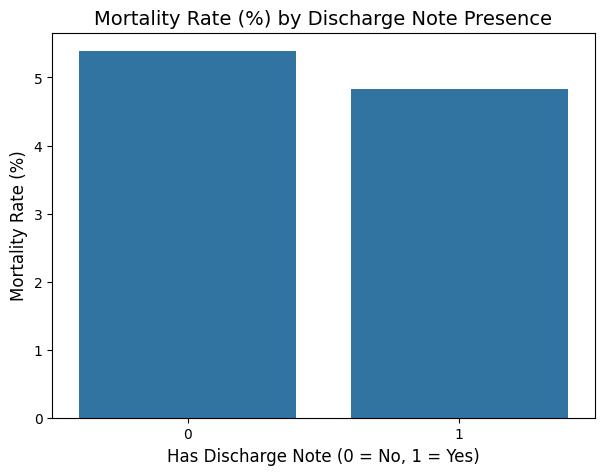

In [12]:
plt.figure(figsize=(7, 5))
sns.barplot(x=mortality_analysis.index, y=mortality_analysis.values)
plt.title('Mortality Rate (%) by Discharge Note Presence', fontsize=14)
plt.xlabel('Has Discharge Note (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Mortality Rate (%)', fontsize=12)
plt.show()

In [13]:
ami_notes_with_outcome = notes_df.merge(
    structured_df[['hadm_id', 'hospital_expire_flag']],
    on='hadm_id'
)

print(f"\nCreated merged notes file with {len(ami_notes_with_outcome)} rows for text analysis.")
print(ami_notes_with_outcome.head())


Created merged notes file with 27677 rows for text analysis.
    hadm_id                                               text  \
0  27897940   \nName:  ___               Unit No:   ___\n \...   
1  26913865   \nName:  ___          Unit No:   ___\n \nAdmi...   
2  24947999   \nName:  ___          Unit No:   ___\n \nAdmi...   
3  25242409   \nName:  ___          Unit No:   ___\n \nAdmi...   
4  25911675   \nName:  ___          Unit No:   ___\n \nAdmi...   

   hospital_expire_flag  
0                     0  
1                     0  
2                     0  
3                     0  
4                     0  


In [15]:
print("\nCalculating word counts for each note...")
# Ensure text is string and fill any (rare) NaNs with empty string
ami_notes_with_outcome['text'] = ami_notes_with_outcome['text'].astype(str).fillna('')
# Calculate word count by splitting on whitespace
ami_notes_with_outcome['note_word_count'] = ami_notes_with_outcome['text'].str.split().str.len()

print("\n--- Word Count Statistics by Outcome ---")
print(ami_notes_with_outcome.groupby('hospital_expire_flag')['note_word_count'].describe())


Calculating word counts for each note...

--- Word Count Statistics by Outcome ---
                        count         mean         std    min     25%     50%  \
hospital_expire_flag                                                            
0                     26340.0  1880.834396  684.101125   85.0  1408.0  1787.0   
1                      1337.0  1576.782349  688.805835  138.0  1092.0  1482.0   

                         75%     max  
hospital_expire_flag                  
0                     2237.0  7932.0  
1                     1942.0  4676.0  


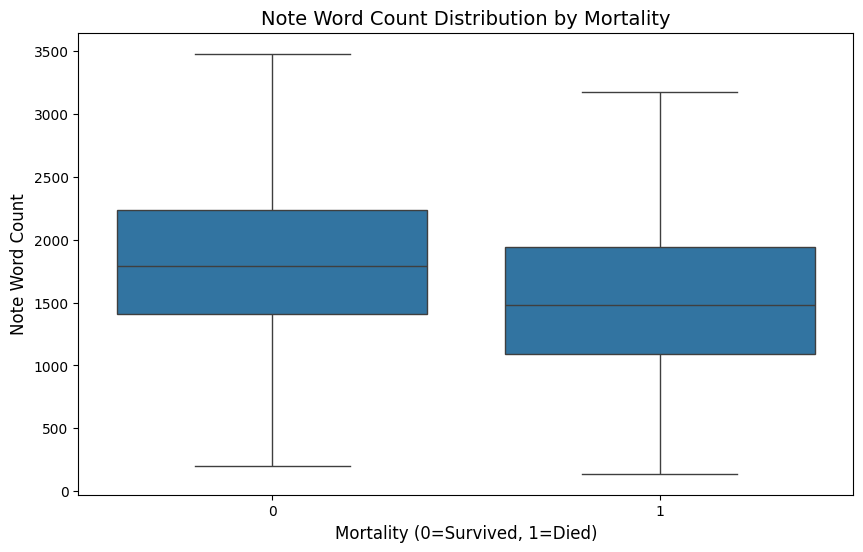

In [16]:
plt.figure(figsize=(10, 6))
# Boxplots are great for comparing distributions
sns.boxplot(data=ami_notes_with_outcome,
            x='hospital_expire_flag',
            y='note_word_count',
            showfliers=False)  # Hides the extreme outliers to see the boxes
plt.title('Note Word Count Distribution by Mortality', fontsize=14)
plt.xlabel('Mortality (0=Survived, 1=Died)', fontsize=12)
plt.ylabel('Note Word Count', fontsize=12)
plt.show()

# N-gram Analysis

In [18]:
import pandas as pd
import os
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

In [19]:
try:
    nltk.data.find('corpora/stopwords')
    print("Stopwords already downloaded.")
except LookupError:
    print("Downloading stopwords...")
    nltk.download('stopwords')

Stopwords already downloaded.


In [20]:
stop_words = set(stopwords.words('english'))

In [21]:
def preprocess_text(text):
    text = str(text).lower()  # Lowercase
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace

    # Remove stopwords
    words = [word for word in text.split() if word not in stop_words]
    return ' '.join(words)

In [22]:
ami_notes_with_outcome['clean_text'] = ami_notes_with_outcome['text'].apply(preprocess_text)

In [23]:
corpus_survived = ami_notes_with_outcome[ami_notes_with_outcome['hospital_expire_flag'] == 0]['clean_text']
corpus_died = ami_notes_with_outcome[ami_notes_with_outcome['hospital_expire_flag'] == 1]['clean_text']

In [24]:
def get_top_ngrams(corpus, ngram_range=(1, 1), n=20):
    vec = CountVectorizer(ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx])
                  for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]




In [25]:
print("\n--- Top 20 Bigrams (2-word phrases) in MORTALITY Notes ---")
top_bigrams_died = get_top_ngrams(corpus_died, ngram_range=(2, 2), n=20)
print(top_bigrams_died)

print("\n--- Top 20 Trigrams (3-word phrases) in MORTALITY Notes ---")
top_trigrams_died = get_top_ngrams(corpus_died, ngram_range=(3, 3), n=20)
print(top_trigrams_died)


--- Top 20 Bigrams (2-word phrases) in MORTALITY Notes ---
[('___ pm', np.int64(11220)), ('___ ___', np.int64(8487)), ('___ blood', np.int64(8378)), ('mg po', np.int64(8213)), ('pm blood', np.int64(7602)), ('po daily', np.int64(4986)), ('date ___', np.int64(2956)), ('left ventricular', np.int64(2499)), ('expired discharge', np.int64(2470)), ('physical exam', np.int64(2201)), ('hgb hct', np.int64(2110)), ('wbc rbc', np.int64(2104)), ('rbc hgb', np.int64(2081)), ('hct mcv', np.int64(2066)), ('mcv mch', np.int64(2053)), ('mch mchc', np.int64(2052)), ('na cl', np.int64(2050)), ('mchc rdw', np.int64(2047)), ('blood ___', np.int64(1941)), ('blood glucose', np.int64(1905))]

--- Top 20 Trigrams (3-word phrases) in MORTALITY Notes ---
[('___ pm blood', np.int64(7600)), ('mg po daily', np.int64(3894)), ('wbc rbc hgb', np.int64(2078)), ('rbc hgb hct', np.int64(2072)), ('hgb hct mcv', np.int64(2064)), ('hct mcv mch', np.int64(2052)), ('mcv mch mchc', np.int64(2052)), ('mch mchc rdw', np.int64(20